<a href="https://colab.research.google.com/github/koffifidelek59-collab/customer-analytics/blob/main/Customer-Analytics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# MIT License
#
#@title Copyright (c) 2026 KOUAME Koffi Fidèle { display-mode: "form" }
#
# Permission is hereby granted, free of charge, to any person obtaining a
# copy of this software and associated documentation files (the "Software"),
# to deal in the Software without restriction, including without limitation
# the rights to use, copy, modify, merge, publish, distribute, sublicense,
# and/or sell copies of the Software, and to permit persons to whom the
# Software is furnished to do so, subject to the following conditions:
#
# The above copyright notice and this permission notice shall be included in
# all copies or substantial portions of the Software.
#
# THE SOFTWARE IS PROVIDED "AS IS", WITHOUT WARRANTY OF ANY KIND, EXPRESS OR
# IMPLIED, INCLUDING BUT NOT LIMITED TO THE WARRANTIES OF MERCHANTABILITY,
# FITNESS FOR A PARTICULAR PURPOSE AND NONINFRINGEMENT. IN NO EVENT SHALL
# THE AUTHORS OR COPYRIGHT HOLDERS BE LIABLE FOR ANY CLAIM, DAMAGES OR OTHER
# LIABILITY, WHETHER IN AN ACTION OF CONTRACT, TORT OR OTHERWISE, ARISING
# FROM, OUT OF OR IN CONNECTION WITH THE SOFTWARE OR THE USE OR OTHER
# DEALINGS IN THE SOFTWARE.

### Open in Google Colab

You can run this notebook directly in [Google Colab](https://colab.research.google.com) without installing anything locally. Just click the badge below:

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/koffifidelek59-collab/customer-analytics/blob/main/Customer-Analytics.ipynb)

💡**Note on Hardware**

The whole analysis runs on a standard CPU in under one minute. No GPU is required.

# Data Analysis Internship: Customer Analytics - Data Quality, Measures and Decision Support on 2,100 Customers

## Author
1. KOUAME Koffi Fidèle - WASCAL IMP-EGH (Energy and Green Hydrogen Technology, System Analysis), Abdou Moumouni University, Niamey.

## Contact info
Any correspondence via KOUAME Koffi Fidèle - koffifidelek59@gmail.com

## Overview

This notebook takes the customer purchase register (Task 9) from **raw data** to **decision support**, following the chain required by the brief:

> **Raw data → Clean data → Measures & KPIs → Insights → Decision support**

The register holds **2,150 rows** describing customers and one purchase each: identity and contact fields, age and gender, purchase amount, date and product category, and a satisfaction rating.

The main contributions of this notebook are:

*   **A reproducible cleaning:** every quality defect is detected by a rule, counted and either corrected or flagged. Only exact duplicate rows are removed.
*   **Measures computed on the right base:** every indicator states the population it rests on, so that a figure copied into a slide keeps its meaning.
*   **Tested insights:** every segment difference is reported with its statistical test, so that a pattern produced by chance, or by the period covered, is not presented as a finding.

## Study Goals
By the end of this notebook, the reader will be able to:

1. **Audit the register**: identify the defects that govern every indicator (sentinel ages, out-of-scale ratings, a sentinel date, missing categories, placeholder contact fields).
2. **Clean without losing information**: apply corrections and flags, and justify every decision.
3. **Compute the indicators**: customers, revenue, average ticket, satisfaction, demographic and category mix, each on its correct base.
4. **Test before concluding**: separate real signals from apparent ones (the monthly shape of the dashboard, category and gender differences).
5. **Support decisions**: translate each finding into an action for sales, customer service and data governance.

# Table of Contents
*   [1. Understanding the Analytical Task](#analytical-task)
*   [2. Target Audience](#target-audience)
*   [3. Software Requirements](#software-requirements)
*   [4. Data Description & Datasheet](#data-description)
*   [5. Data Loading](#data-loading)
*   [6. Data Quality Audit](#data-quality)
*   [7. Data Cleaning](#data-cleaning)
*   [8. Measures & KPIs](#measures-kpis)
*   [9. Results & Discussion](#results-and-discussion)
*   [10. Statistical Tests](#statistical-tests)
*   [11. Insights & Recommendations](#insights)
*   [12. Interactive Dashboard & Quality Alerts](#dashboard)
*   [13. Limitations & Future Works](#limitations)
*   [14. References](#references)

<a name="analytical-task"></a>
# 1. Understanding the Analytical Task

Before computing any indicator, it is important to understand **what** the register can support, **why** a naive reading misleads, and **where** each figure is allowed to be used.

## What Are We Measuring?

One row describes one customer and one purchase.

| Question | Indicator | Unit |
|---|---|---|
| How many customers? | Distinct customer identifiers | count |
| How much revenue? | Sum and mean of the purchase amount | currency units ($) |
| What is bought? | Category mix (Books, Clothing, Electronics, Home, Toys) | count, % |
| Who buys? | Gender and age mix | % |
| How satisfied? | Rating on the 1 to 5 scale | score |
| When? | Purchases per calendar month | count |

## Why a Naive Reading Misleads

Several columns look complete or plausible and are not:

- **Sentinel ages.** −1 and 200 are written in place of an unknown age on 1,099 of 2,100 customers. A mean computed on the raw column gives 85 years.
- **Out-of-scale ratings.** 291 ratings equal 10 on a 1 to 5 scale.
- **A sentinel date.** 118 purchases carry the impossible date 32/13/2020.
- **Missing categories.** 565 purchases (26.9%) have no product category, more than any single category.
- **Placeholder contact fields.** The phone column holds only two values (123456789 and 987654321) and 2,100 customers share 144 email addresses.
- **A period that does not cover whole years.** Purchases run from October 2022 to July 2025: a chart that pools all years by month name counts August and September twice but other months three times.

> **Key takeaway:** A figure computed on the raw columns looks complete and is wrong. Every indicator in this notebook is computed on the rows that can support it, and states that base.

<a name="target-audience"></a>
# 2. Target Audience

This notebook is intended for:

*   **Sales and marketing management**, who decide on assortment, targeting and campaigns.
*   **Customer service**, who own the satisfaction indicators.
*   **Data governance and IT**, who own the point-of-sale and customer systems where the defects originate.
*   **Data analysts and students**, who need a reproducible example of the chain from raw data to decision support.

The ideal reader has a working knowledge of Python (pandas, matplotlib) and of basic descriptive and inferential statistics.

<a name="software-requirements"></a>
# 3. Software Requirements

The analysis uses the Python scientific stack only: `pandas`, `numpy`, `scipy` and `matplotlib`. The pipeline tools delivered with the project (`etl/`, `api/`, `airflow/`, `grafana/`) are described in section 12.

`pip freeze > requirements.txt`

In [2]:
# ===============================================================
# @title 📦 Install dependencies
# ===============================================================

# Install pandas and numpy for data manipulation
!pip install -q pandas numpy

# Install scipy for the statistical tests
!pip install -q scipy

# Install matplotlib for the figures
!pip install -q matplotlib

In [3]:
# @title Import libraries and message function

# Standard library imports
import os
import json
import urllib.request
from pprint import pprint

# Third-party imports
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.patches import Patch
import numpy as np
import pandas as pd
import scipy
from scipy import stats
from IPython.display import HTML, display


def show_message(msg: str, color: str = "#1f77b4"):
    """
    Displays a colored message in the notebook output.

    Args:
        msg: The message string to display.
        color: The color of the message text (default is blue).
    """
    display(HTML(f"<p style='color:{color}; font-size:16px; font-weight:bold'>{msg}</p>"))

In [4]:
print(f"pandas version: {pd.__version__}")
print(f"numpy version: {np.__version__}")
print(f"scipy version: {scipy.__version__}")
print(f"matplotlib version: {matplotlib.__version__}")

pandas version: 3.0.6
numpy version: 2.4.6
scipy version: 1.17.1
matplotlib version: 3.11.2


In [5]:
# ================================================================
# @title 🎨 Figure standard (one style for every figure of the report)
# ================================================================
# Every figure is drawn at the width of the report text (16 cm = 6.3 in),
# so that fonts appear at their true size once inserted in the PDF.
# One colour per role, never per bar:
#   - PRIMARY  : the series being measured
#   - MUTED    : data shown for reference only (not for decisions)
#   - CRITICAL : a data defect, always named in a label or legend
#   - RATING   : one-hue ordinal ramp, light (1) to dark (5)
#   - CATEGORY : fixed categorical order, validated for colour-vision deficiency

FIG_WIDTH = 6.3          # inches, text width of the A4 report
PRIMARY = "#2a78d6"
MUTED = "#b4b2ab"
CRITICAL = "#d03b3b"
INK = "#0b0b0b"
INK_SECONDARY = "#52514e"
GRID = "#e1e0d9"
AXIS = "#8a8983"
RATING_COLORS = ["#c6dcf7", "#86b6ef", "#4f93e3", "#2a78d6", "#104281"]   # 1 to 5, light to dark
CATEGORY_COLORS = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4"]
GENDER_COLORS = {"Female": "#e87ba4", "Male": "#2a78d6", "Unknown": MUTED}


def set_plot_style():
    """
    Applies the report figure standard to matplotlib.

    Sans-serif text at 9 pt, hairline axes, horizontal grid only,
    no top or right spine, white background.
    """
    plt.rcParams.update({
        "font.family": "sans-serif",
        "font.sans-serif": ["Liberation Sans", "Arial", "Helvetica", "DejaVu Sans"],
        "font.size": 9,
        "axes.titlesize": 9.5,
        "axes.titleweight": "bold",
        "axes.titlelocation": "left",
        "axes.titlepad": 8,
        "axes.labelsize": 9,
        "axes.labelcolor": INK_SECONDARY,
        "axes.edgecolor": AXIS,
        "axes.linewidth": 0.6,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": False,
        "grid.color": GRID,
        "grid.linewidth": 0.6,
        "xtick.color": INK_SECONDARY,
        "ytick.color": INK_SECONDARY,
        "xtick.labelsize": 8.5,
        "ytick.labelsize": 8.5,
        "xtick.major.width": 0.6,
        "ytick.major.width": 0.6,
        "xtick.major.size": 3,
        "ytick.major.size": 0,
        "legend.fontsize": 8.5,
        "legend.frameon": False,
        "figure.dpi": 110,
        "savefig.dpi": 300,
        "figure.facecolor": "white",
        "axes.facecolor": "white",
        "pdf.fonttype": 42,
    })


def thousands(x: float, _=None) -> str:
    """
    Formats an axis tick with a thousands separator.

    Args:
        x: The tick value.

    Returns:
        The formatted tick label, for example 150,000.
    """
    return f"{x:,.0f}"


set_plot_style()
print("✅ Figure standard applied.")

✅ Figure standard applied.


<a name="data-description"></a>
# 4. Data Description & Datasheet

The data is the customer purchase extract supplied for Task 9 of the internship (`customers_raw.csv`).

## Datasheet for the Register

Datasheets for Datasets ([Gebru et al., 2021](https://arxiv.org/abs/1803.09010)) document key properties of a dataset to support responsible, informed use. Below is a condensed datasheet for the register.

### Motivation
- **What is the purpose of this dataset?** To support the analysis of customers, purchases, product categories and satisfaction for one retailer.
- **Who created it?** The retailer's customer and point-of-sale systems, supplied as a training dataset for the data analysis internship.

### Composition
- **What does an instance represent?** One customer and one purchase.
- **Number of instances:** 2,150 rows, 2,100 distinct customer identifiers (CUST1000 to CUST3099).
- **Period:** 27 October 2022 to 23 July 2025, for the purchases with a valid date.
- **Key columns:**

| Column | Content |
|---|---|
| `CustomerID` | Customer identifier |
| `Name`, `Email`, `Phone` | Identity and contact fields |
| `Age`, `Gender` | Demographics; gender written in six spellings (M, male, Male, F, female, Female) |
| `PurchaseAmount` | Amount of the purchase, $ |
| `PurchaseDate` | Date of the purchase, month/day/year |
| `ProductCategory` | Books, Clothing, Electronics, Home, Toys |
| `Rating` | Satisfaction rating, scale 1 to 5 |
| `Unnamed`, `  Gender  ` | Two export artefacts: an empty column and an exact copy of `Gender` |

### Collection Process
- Records are captured at the point of sale and in the customer file. The extract was exported to CSV with two artefact columns.

### Uses
- **Intended use:** Descriptive analysis, decision support, training.
- **Potential misuse:** Publishing a mean age or a mean rating on the raw columns; contacting customers through the phone or email columns; reading the pooled monthly chart as seasonality.

### Limitations & Gaps
- One purchase per customer: no repeat-purchase, retention or lifetime-value analysis is possible.
- No store, channel, price or margin column: revenue is a sales amount, not a profit.
- The names (48 distinct values) and contact fields indicate a synthetic or anonymised extract.

<a name="data-loading"></a>

# 5. Data Loading

⚠️**Data Access Options**

This notebook offers two ways to access the register:

* Option 1 - Local copy: if the notebook runs from the project folder, the register is read from `./data/customers_raw.csv`.

* Option 2 - GitHub: if the local copy is missing (for example in Google Colab), the register is downloaded from the project repository. No authentication is required.

In [6]:
# @title Drive Location for data, plots and results

def make_directory(drive_path: str):
    """
    Checks if a directory exists at the given path and creates it if it doesn't.

    Args:
        drive_path: The path to the directory.
    """
    if not os.path.exists(drive_path):
        os.makedirs(drive_path)
        print(f"Folder created: {drive_path}")
    else:
        print(f"Folder already exists: {drive_path}")


# Adjust the paths according to your directory structure.
drive_data_path = "./data/"
drive_plots_path = "./figures/"
drive_results_path = "./results/"

make_directory(drive_data_path)
make_directory(drive_plots_path)
make_directory(drive_results_path)

Folder already exists: ./data/
Folder already exists: ./figures/
Folder already exists: ./results/


In [7]:
# @title 🛒 Data Access Options: Local copy or GitHub
# ===============================================================
# Option 1 → Read the local copy in ./data/
# Option 2 → Download the register from the project repository
# ===============================================================

RAW_FILE = drive_data_path + "customers_raw.csv"
GITHUB_RAW_URL = ("https://raw.githubusercontent.com/koffifidelek59-collab/customer-analytics/"
                  "main/data/customers_raw.csv")

if os.path.exists(RAW_FILE):
    show_message(f"✅ Local register found: {RAW_FILE}", "#228B22")
else:
    show_message("🌍 Local register not found. Downloading from GitHub...", "#1f77b4")
    urllib.request.urlretrieve(GITHUB_RAW_URL, RAW_FILE)
    show_message(f"✅ Register downloaded to {RAW_FILE}", "#228B22")

In [8]:
# @title Load the raw register

# Every column is kept exactly as supplied; types are fixed in the cleaning step.
raw_df = pd.read_csv(RAW_FILE)
print(f"raw_df size: {raw_df.shape}")
print("First 5 rows of the raw register:")
raw_df.head()

raw_df size: (2150, 12)
First 5 rows of the raw register:


,CustomerID,Name,Age,Gender,Email,Phone,PurchaseAmount,PurchaseDate,ProductCategory,Rating,Unnamed,Gender
0,CUST1000,Ali Hassan,72.0,NaN,ali.hassan@gmail.com,123456789.0,837.31,10/12/2023,Books,3.0,NaN,NaN
1,CUST1001,Fatma Ali,NaN,Female,fatma.ali@hotmail.com,NaN,900.25,2/23/2023,NaN,3.0,NaN,Female
2,CUST1002,Ahmed Mahmoud,-1.0,male,ahmed.mahmoud@hotmail.com,NaN,761.72,7/7/2023,Toys,2.0,NaN,male
3,CUST1003,Ahmed Gaber,-1.0,F,ahmed.gaber@gmail.com,NaN,303.72,12/30/2023,NaN,2.0,NaN,F
4,CUST1004,Ali Ibrahim,73.0,M,ali.ibrahim@yahoo.com,987654321.0,635.81,12/7/2023,Clothing,2.0,NaN,M


In [9]:
# @title Column types, missing values and distinct values

overview = pd.DataFrame({
    "dtype": raw_df.dtypes.astype(str),
    "missing": raw_df.isna().sum(),
    "missing_%": (raw_df.isna().mean() * 100).round(1),
    "distinct": raw_df.nunique(),
})
overview

,dtype,missing,missing_%,distinct
CustomerID,str,0,0.0,2100
Name,str,0,0.0,48
Age,float64,520,24.2,78
Gender,str,273,12.7,6
Email,str,0,0.0,144
Phone,float64,1078,50.1,2
PurchaseAmount,float64,101,4.7,1991
PurchaseDate,str,0,0.0,860
ProductCategory,str,577,26.8,5
Rating,float64,329,15.3,6


<a name="data-quality"></a>
# 6. Data Quality Audit

The audit runs eight checks, one per defect family. Each check is computed on the raw register and counted twice: on the 2,150 rows as supplied, and on the 2,100 customers that remain after duplicates are removed (the base of every later indicator).

In [10]:
# @title Check 1: duplicate rows and duplicate identifiers

dup_ids = int(raw_df["CustomerID"].duplicated().sum())
dup_rows = int(raw_df.duplicated().sum())
print(f"Duplicate CustomerID: {dup_ids}")
print(f"Exact duplicate rows : {dup_rows}")
print(f"Every duplicate identifier is an exact copy of its first row: {dup_ids == dup_rows}")

# The rest of the audit is counted on one row per customer.
dedup = raw_df.drop_duplicates(subset="CustomerID", keep="first")
print(f"Customers after de-duplication: {len(dedup)}")

Duplicate CustomerID: 50
Exact duplicate rows : 50
Every duplicate identifier is an exact copy of its first row: True
Customers after de-duplication: 2100


In [11]:
# @title Check 2: export artefacts

print(f"'Unnamed' column empty on every row: {raw_df['Unnamed'].isna().all()}")
same_gender = raw_df["Gender"].fillna("<NA>").eq(raw_df["  Gender  "].fillna("<NA>")).all()
print(f"'  Gender  ' is an exact copy of 'Gender': {same_gender}")

'Unnamed' column empty on every row: True
'  Gender  ' is an exact copy of 'Gender': True


In [12]:
# @title Check 3: sentinel ages

age_status = pd.Series({
    "Valid age (1 to 100)": int(dedup["Age"].between(1, 100).sum()),
    "Sentinel -1": int((dedup["Age"] == -1).sum()),
    "Sentinel 200": int((dedup["Age"] == 200).sum()),
    "Missing": int(dedup["Age"].isna().sum()),
})
print(age_status.to_string())
print(f"\nMean of the raw column: {dedup['Age'].mean():.1f} years  (meaningless)")
print(f"Mean of the valid ages : {dedup['Age'].where(dedup['Age'].between(1, 100)).mean():.1f} years")

Valid age (1 to 100)    495
Sentinel -1             553
Sentinel 200            546
Missing                 506

Mean of the raw column: 85.0 years  (meaningless)
Mean of the valid ages : 54.4 years


In [13]:
# @title Check 4: ratings outside the 1 to 5 scale

rating_counts = dedup["Rating"].value_counts(dropna=False).sort_index()
print(rating_counts.to_string())
print(f"\nRatings equal to 10: {int((dedup['Rating'] == 10).sum())}")
print(f"Mean of the raw column: {dedup['Rating'].mean():.2f}  (inflated by the 10s)")

Rating
1.0     266
2.0     310
3.0     326
4.0     278
5.0     307
10.0    291
NaN     322

Ratings equal to 10: 291
Mean of the raw column: 4.17  (inflated by the 10s)


In [14]:
# @title Check 5: the sentinel purchase date

parsed = pd.to_datetime(dedup["PurchaseDate"], format="%m/%d/%Y", errors="coerce")
bad_dates = dedup.loc[parsed.isna(), "PurchaseDate"].value_counts()
print("Unparseable dates:")
print(bad_dates.to_string())
print(f"\nValid dates run from {parsed.min():%d %B %Y} to {parsed.max():%d %B %Y}")

Unparseable dates:
PurchaseDate
32/13/2020    118

Valid dates run from 27 October 2022 to 23 July 2025


In [15]:
# @title Check 6: gender spellings and missing categories

print("Gender as supplied:")
print(dedup["Gender"].value_counts(dropna=False).to_string())
print("\nProduct category as supplied:")
print(dedup["ProductCategory"].value_counts(dropna=False).to_string())

Gender as supplied:
Gender
M         335
Female    309
Male      309
male      298
F         293
female    289
NaN       267

Product category as supplied:
ProductCategory
NaN            565
Clothing       323
Electronics    323
Books          305
Home           296
Toys           288


In [16]:
# @title Check 7: contact fields

print("Distinct phone numbers:", dedup["Phone"].dropna().unique())
print(f"Customers without a phone: {int(dedup['Phone'].isna().sum())}")
print(f"Distinct emails for {len(dedup)} customers: {dedup['Email'].nunique()}")
print(f"Distinct names: {dedup['Name'].nunique()}")

Distinct phone numbers: [1.23456789e+08 9.87654321e+08]
Customers without a phone: 1057
Distinct emails for 2100 customers: 144
Distinct names: 48


In [17]:
# @title Check 8: purchase amount range and completeness

print(dedup["PurchaseAmount"].describe().round(2).to_string())
print(f"\nMissing amounts: {int(dedup['PurchaseAmount'].isna().sum())}")

count    2003.00
mean      509.90
std       288.49
min         5.06
25%       263.50
50%       519.42
75%       765.18
max       999.56

Missing amounts: 97


**Remark** ✅

- **Duplicates are exact copies.** The 50 duplicate identifiers repeat their first row field by field, so removing them loses no information.
- **Age is the weakest column.** Only 495 of 2,100 customers (23.6%) have a usable age: 553 carry −1, 546 carry 200 and 506 are empty.
- **291 ratings equal 10.** They are not a different scale: the other values cover 1 to 5 evenly.
- **All 118 invalid dates are the same string, 32/13/2020.** It is a sentinel, not a typing error.
- **Contact fields are placeholders.** Two phone values and 144 emails for 2,100 customers: no campaign can be addressed from this file.
- **Purchase amounts are clean.** They range from 5.06 to 999.56, with 97 missing (4.6%).

In [18]:
# @title Quality summary table

quality_summary = pd.DataFrame([
    ("Rows as supplied", len(raw_df), len(raw_df)),
    ("Duplicate rows (exact copies)", dup_rows, len(raw_df)),
    ("Customers after de-duplication", len(dedup), len(dedup)),
    ("Age missing or sentinel (-1, 200)", int((~dedup["Age"].between(1, 100)).sum()), len(dedup)),
    ("Rating missing", int(dedup["Rating"].isna().sum()), len(dedup)),
    ("Rating out of scale (10)", int((dedup["Rating"] == 10).sum()), len(dedup)),
    ("Purchase date invalid (32/13/2020)", int(parsed.isna().sum()), len(dedup)),
    ("Product category missing", int(dedup["ProductCategory"].isna().sum()), len(dedup)),
    ("Gender missing", int(dedup["Gender"].isna().sum()), len(dedup)),
    ("Purchase amount missing", int(dedup["PurchaseAmount"].isna().sum()), len(dedup)),
    ("Phone missing or placeholder", len(dedup), len(dedup)),
], columns=["check", "rows", "base"])
quality_summary["share_%"] = (quality_summary["rows"] / quality_summary["base"] * 100).round(2)
quality_summary.to_csv(drive_results_path + "data_quality_summary.csv", index=False)
quality_summary

,check,rows,base,share_%
0,Rows as supplied,2150,2150,100.00
1,Duplicate rows (exact copies),50,2150,2.33
2,Customers after de-duplication,2100,2100,100.00
3,"Age missing or sentinel (-1, 200)",1605,2100,76.43
4,Rating missing,322,2100,15.33
5,Rating out of scale (10),291,2100,13.86
6,Purchase date invalid (32/13/2020),118,2100,5.62
7,Product category missing,565,2100,26.90
8,Gender missing,267,2100,12.71
9,Purchase amount missing,97,2100,4.62


<a name="data-cleaning"></a>
# 7. Data Cleaning

The cleaning follows one principle: **correct what is certain, flag what is not, delete only exact copies**. A row with a sentinel age still carries a valid purchase, rating and category; deleting it would bias every other indicator.

| Rule | Action | Rows affected |
|---|---|---|
| Export artefacts | Drop `Unnamed` and the copy of `Gender` | columns only |
| Duplicate CustomerID | Keep the first row (exact copies) | 50 |
| Gender | Map six spellings to Male / Female | 1,833 |
| Age outside 1 to 100 | Set to missing | 1,099 |
| Rating outside 1 to 5 | Set to missing | 291 |
| Sentinel date | Flag `DateInvalid`, date set to missing | 118 |
| Missing category | Label `Unknown` | 565 |
| Missing amount | Flag `AmountMissing`, kept missing | 97 |

These rules are the ones implemented in the production pipeline `etl/run_etl.py`; the cell after the cleaning checks that both produce the same table.

In [19]:
# @title Clean the register

AGE_RANGE = (1, 100)
RATING_RANGE = (1, 5)
AGE_BANDS = [0, 18, 30, 45, 60, 75, 200]
AGE_BAND_LABELS = ["0-18", "19-30", "31-45", "46-60", "61-75", "76+"]
MONTH_NAMES = {1: "Jan", 2: "Feb", 3: "Mar", 4: "Apr", 5: "May", 6: "Jun",
               7: "Jul", 8: "Aug", 9: "Sep", 10: "Oct", 11: "Nov", 12: "Dec"}
GENDER_MAP = {"m": "Male", "male": "Male", "f": "Female", "female": "Female"}


def clean_register(df: pd.DataFrame) -> pd.DataFrame:
    """
    Builds the analysis-ready register from the raw extract.

    Args:
        df: The raw register as supplied.

    Returns:
        The cleaned register, one row per customer, with the quality flags.
    """
    out = df.drop(columns=["Unnamed", "  Gender  "])
    out = out.drop_duplicates(subset="CustomerID", keep="first").copy()

    out["Gender"] = out["Gender"].str.strip().str.lower().map(GENDER_MAP)
    out["Age"] = out["Age"].where(out["Age"].between(*AGE_RANGE))
    out["Rating"] = out["Rating"].where(out["Rating"].between(*RATING_RANGE))
    out["AmountMissing"] = out["PurchaseAmount"].isna()

    parsed = pd.to_datetime(out["PurchaseDate"], format="%m/%d/%Y", errors="coerce")
    out["DateInvalid"] = parsed.isna()
    out["PurchaseDate"] = parsed.dt.strftime("%Y-%m-%d")
    out["PurchaseMonth"] = parsed.dt.month
    out["PurchaseMonthName"] = parsed.dt.month.map(MONTH_NAMES)

    out["ProductCategory"] = out["ProductCategory"].fillna("Unknown")
    band = pd.cut(out["Age"], bins=AGE_BANDS, labels=AGE_BAND_LABELS)
    out["AgeBand"] = band.astype(str).where(band.notna(), "Unknown")
    return out.reset_index(drop=True)


clean_df = clean_register(raw_df)
clean_df.to_csv(drive_data_path + "customers_clean.csv", index=False)
print(f"clean_df size: {clean_df.shape}")
clean_df.head()

clean_df size: (2100, 15)


,CustomerID,Name,Age,Gender,Email,Phone,PurchaseAmount,PurchaseDate,ProductCategory,Rating,AmountMissing,DateInvalid,PurchaseMonth,PurchaseMonthName,AgeBand
0,CUST1000,Ali Hassan,72.0,NaN,ali.hassan@gmail.com,123456789.0,837.31,2023-10-12,Books,3.0,False,False,10.0,Oct,61-75
1,CUST1001,Fatma Ali,NaN,Female,fatma.ali@hotmail.com,NaN,900.25,2023-02-23,Unknown,3.0,False,False,2.0,Feb,Unknown
2,CUST1002,Ahmed Mahmoud,NaN,Male,ahmed.mahmoud@hotmail.com,NaN,761.72,2023-07-07,Toys,2.0,False,False,7.0,Jul,Unknown
3,CUST1003,Ahmed Gaber,NaN,Female,ahmed.gaber@gmail.com,NaN,303.72,2023-12-30,Unknown,2.0,False,False,12.0,Dec,Unknown
4,CUST1004,Ali Ibrahim,73.0,Male,ali.ibrahim@yahoo.com,987654321.0,635.81,2023-12-07,Clothing,2.0,False,False,12.0,Dec,61-75


In [20]:
# @title Cross-check against the production ETL (etl/run_etl.py)

ETL_FILE = "./etl/run_etl.py"
if os.path.exists(ETL_FILE):
    import importlib.util
    spec = importlib.util.spec_from_file_location("run_etl", ETL_FILE)
    run_etl = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(run_etl)
    etl_df, etl_audit = run_etl.transform(run_etl.extract(__import__("pathlib").Path(RAW_FILE)))
    etl_df = etl_df.reset_index(drop=True)
    common = ["CustomerID", "Age", "Gender", "PurchaseAmount", "PurchaseDate",
              "ProductCategory", "Rating", "DateInvalid", "AgeBand"]
    same = all(etl_df[c].astype(str).equals(clean_df[c].astype(str)) for c in common)
    show_message(f"✅ Notebook cleaning and ETL pipeline agree on every column: {same}", "#228B22")
else:
    show_message("ℹ️ etl/run_etl.py not found (for example in Colab): cross-check skipped.")

<a name="measures-kpis"></a>
# 8. Measures & KPIs

Each indicator is computed on the population that can support it, and that population is stored with the value.

In [21]:
# @title Compute the KPI table

def compute_kpis(df: pd.DataFrame) -> pd.DataFrame:
    """
    Computes the headline indicators with the base each one rests on.

    Args:
        df: The cleaned register.

    Returns:
        A DataFrame with the metric, its value and its base.
    """
    gender = df["Gender"].dropna()
    rows = [
        ("total_customers", len(df), "distinct CustomerID"),
        ("total_revenue", df["PurchaseAmount"].sum(), f"{df['PurchaseAmount'].notna().sum()} amounts"),
        ("avg_purchase", df["PurchaseAmount"].mean(), f"{df['PurchaseAmount'].notna().sum()} amounts"),
        ("median_purchase", df["PurchaseAmount"].median(), f"{df['PurchaseAmount'].notna().sum()} amounts"),
        ("avg_rating", df["Rating"].mean(), f"{df['Rating'].notna().sum()} ratings on 1-5"),
        ("low_rating_pct", (df["Rating"] <= 2).sum() / df["Rating"].notna().sum() * 100,
         f"{df['Rating'].notna().sum()} ratings on 1-5"),
        ("avg_age", df["Age"].mean(), f"{df['Age'].notna().sum()} valid ages"),
        ("pct_male", (gender == "Male").mean() * 100, f"{len(gender)} known genders"),
        ("pct_female", (gender == "Female").mean() * 100, f"{len(gender)} known genders"),
        ("unknown_category", int((df["ProductCategory"] == "Unknown").sum()), "all customers"),
        ("unknown_category_pct", (df["ProductCategory"] == "Unknown").mean() * 100, "all customers"),
        ("invalid_dates", int(df["DateInvalid"].sum()), "all customers"),
        ("invalid_dates_pct", df["DateInvalid"].mean() * 100, "all customers"),
        ("missing_amount_pct", df["AmountMissing"].mean() * 100, "all customers"),
        ("valid_age_pct", df["Age"].notna().mean() * 100, "all customers"),
    ]
    return pd.DataFrame(rows, columns=["metric", "value", "base"])


kpi_df = compute_kpis(clean_df)
kpi_df.to_csv(drive_results_path + "kpis.csv", index=False)
with pd.option_context("display.float_format", "{:,.2f}".format):
    display(kpi_df)

,metric,value,base
0,total_customers,"2,100.00",distinct CustomerID
1,total_revenue,"1,021,324.45",2003 amounts
2,avg_purchase,509.90,2003 amounts
3,median_purchase,519.42,2003 amounts
4,avg_rating,3.03,1487 ratings on 1-5
5,low_rating_pct,38.74,1487 ratings on 1-5
6,avg_age,54.37,495 valid ages
7,pct_male,51.39,1833 known genders
8,pct_female,48.61,1833 known genders
9,unknown_category,565.00,all customers


In [22]:
# @title Aggregated tables by category, gender, age band and month

def summarise_by(df: pd.DataFrame, key: str) -> pd.DataFrame:
    """
    Summarises customers, revenue, average ticket and rating for one dimension.

    Args:
        df: The cleaned register.
        key: The column to group by.

    Returns:
        A DataFrame with one row per category of the dimension.
    """
    table = df.groupby(key, dropna=False).agg(
        customers=("CustomerID", "count"),
        revenue=("PurchaseAmount", "sum"),
        avg_purchase=("PurchaseAmount", "mean"),
        ratings=("Rating", "count"),
        avg_rating=("Rating", "mean"),
    )
    table["share_%"] = table["customers"] / len(df) * 100
    return table.round(2).sort_values("customers", ascending=False)


summary_tables: dict = {}
for key, name in [("ProductCategory", "category"), ("Gender", "gender"),
                  ("AgeBand", "ageband"), ("PurchaseMonthName", "month")]:
    data = clean_df.assign(Gender=clean_df["Gender"].fillna("Unknown"))
    summary_tables[name] = summarise_by(data, key)
    summary_tables[name].to_csv(drive_results_path + f"by_{name}.csv")

print(summary_tables["category"].to_string())

                 customers    revenue  avg_purchase  ratings  avg_rating  share_%
ProductCategory                                                                  
Unknown                565  267729.35        496.71      415        3.01    26.90
Clothing               323  163864.98        537.26      232        3.06    15.38
Electronics            323  154691.51        500.62      229        3.11    15.38
Books                  305  150083.23        510.49      209        2.96    14.52
Home                   296  143571.07        500.25      193        3.04    14.10
Toys                   288  141384.31        525.59      209        3.01    13.71


<a name="results-and-discussion"></a>
# 9. Results & Discussion

This section produces the eight figures of the report. Each function draws one figure, saves it in PNG at 300 dpi, and returns it.

All figures follow the same standard: one colour per role, values written only where the reader needs them, the message of the figure in the report caption rather than inside the plot.

In [23]:
# @title Save a figure in PNG

def save_figure(fig: plt.Figure, name: str):
    """
    Saves a figure in the plots folder, in PNG at 300 dpi.

    Args:
        fig: The matplotlib figure.
        name: The file name without extension.
    """
    fig.savefig(drive_plots_path + f"{name}.png", dpi=300, bbox_inches="tight")
    print(f"Saved: {drive_plots_path}{name}.png")


def label_bars_h(ax: plt.Axes, bars, labels: list, pad: float = 0.01):
    """
    Writes one label at the end of each horizontal bar.

    Args:
        ax: The axes holding the bars.
        bars: The bar container returned by ax.barh.
        labels: The text to write, one per bar.
        pad: The gap between bar end and label, as a share of the x range.
    """
    x_range = ax.get_xlim()[1] - ax.get_xlim()[0]
    for bar, text in zip(bars, labels):
        ax.text(bar.get_width() + pad * x_range, bar.get_y() + bar.get_height() / 2,
                text, va="center", ha="left", fontsize=8, color=INK, zorder=4,
                bbox={"facecolor": "white", "edgecolor": "none", "pad": 0.4})


def label_bars_v(ax: plt.Axes, bars, labels: list, pad: float = 0.015):
    """
    Writes one label above each vertical bar.

    Args:
        ax: The axes holding the bars.
        bars: The bar container returned by ax.bar.
        labels: The text to write, one per bar.
        pad: The gap between bar top and label, as a share of the y range.
    """
    y_range = ax.get_ylim()[1] - ax.get_ylim()[0]
    for bar, text in zip(bars, labels):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + pad * y_range,
                text, va="bottom", ha="center", fontsize=8, color=INK, zorder=4,
                bbox={"facecolor": "white", "edgecolor": "none", "pad": 0.4})

## Figure 1 - Usable share of each column

For every analytical column, the share of the 2,100 customers that carries a usable value after cleaning. Columns below 80% are drawn in red.

Saved: ./figures/01_data_quality.png


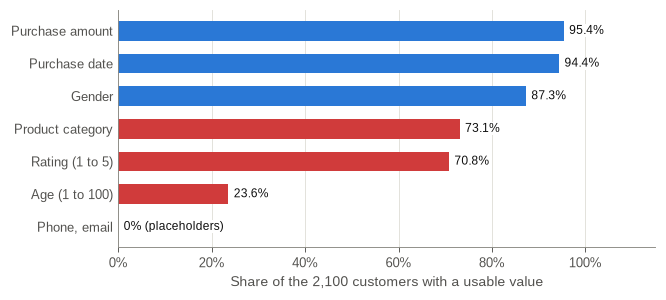

In [24]:
# @title Figure 1: Usable share of each column after cleaning

def plot_completeness(df: pd.DataFrame) -> plt.Figure:
    """
    Plots the share of customers with a usable value in each analytical column.

    Args:
        df: The cleaned register.

    Returns:
        The matplotlib figure.
    """
    usable = pd.Series({
        "Purchase amount": df["PurchaseAmount"].notna().mean(),
        "Purchase date": (~df["DateInvalid"]).mean(),
        "Gender": df["Gender"].notna().mean(),
        "Product category": (df["ProductCategory"] != "Unknown").mean(),
        "Rating (1 to 5)": df["Rating"].notna().mean(),
        "Age (1 to 100)": df["Age"].notna().mean(),
        "Phone, email": 0.0,
    }) * 100
    usable = usable.sort_values()
    colors = [CRITICAL if v < 80 else PRIMARY for v in usable.values]

    fig, ax = plt.subplots(figsize=(FIG_WIDTH, 2.8))
    bars = ax.barh(usable.index, usable.values, color=colors, height=0.6)
    ax.set_xlim(0, 115)
    ax.xaxis.set_major_formatter(mticker.PercentFormatter(decimals=0))
    ax.set_xticks([0, 20, 40, 60, 80, 100])
    ax.set_xlabel("Share of the 2,100 customers with a usable value")
    ax.xaxis.grid(True)
    ax.set_axisbelow(True)
    labels = [f"{v:.1f}%" if v > 0 else "0% (placeholders)" for v in usable.values]
    label_bars_h(ax, bars, labels)
    return fig


fig = plot_completeness(clean_df)
save_figure(fig, "01_data_quality")
plt.show()

## Figure 2 - What the age and rating columns really contain

Saved: ./figures/02_age_rating_raw.png


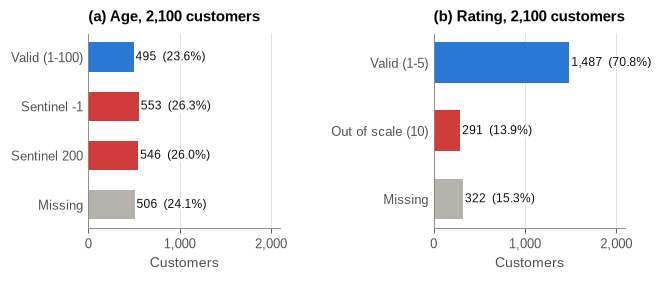

In [25]:
# @title Figure 2: Composition of the raw age and rating columns

def plot_age_rating_raw(df: pd.DataFrame) -> plt.Figure:
    """
    Splits the raw age and rating columns into usable values and defects.

    Args:
        df: The de-duplicated raw register (one row per customer).

    Returns:
        The matplotlib figure.
    """
    age = pd.Series({
        "Valid (1-100)": df["Age"].between(1, 100).sum(),
        "Sentinel -1": (df["Age"] == -1).sum(),
        "Sentinel 200": (df["Age"] == 200).sum(),
        "Missing": df["Age"].isna().sum(),
    })
    rating = pd.Series({
        "Valid (1-5)": df["Rating"].between(1, 5).sum(),
        "Out of scale (10)": (df["Rating"] == 10).sum(),
        "Missing": df["Rating"].isna().sum(),
    })
    n = len(df)
    fig, axes = plt.subplots(1, 2, figsize=(FIG_WIDTH, 2.3), gridspec_kw={"wspace": 0.8})
    for ax, series, title in [(axes[0], age, "(a) Age, 2,100 customers"),
                              (axes[1], rating, "(b) Rating, 2,100 customers")]:
        colors = [PRIMARY] + [CRITICAL] * (len(series) - 2) + [MUTED]
        bars = ax.barh(series.index[::-1], series.values[::-1], color=colors[::-1], height=0.6)
        ax.set_xlim(0, 2100)
        ax.xaxis.set_major_formatter(mticker.FuncFormatter(thousands))
        ax.set_xlabel("Customers")
        ax.set_title(title)
        ax.xaxis.grid(True)
        ax.set_axisbelow(True)
        label_bars_h(ax, bars, [f"{v:,}  ({v / n * 100:.1f}%)" for v in series.values[::-1]])
    return fig


fig = plot_age_rating_raw(dedup)
save_figure(fig, "02_age_rating_raw")
plt.show()

## Figure 3 - Customers and revenue by product category

Both panels share the same category order. `Unknown` is drawn in grey: it is a capture gap, not a category.

Saved: ./figures/03_categories.png


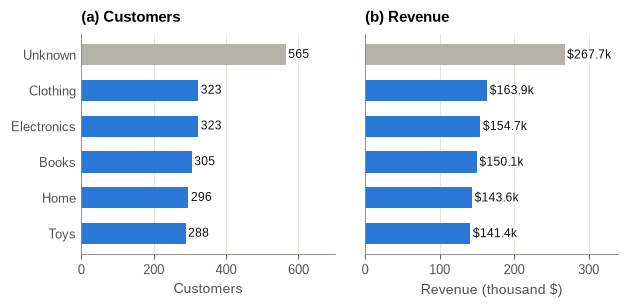

In [26]:
# @title Figure 3: Customers and revenue by product category

def plot_categories(table: pd.DataFrame) -> plt.Figure:
    """
    Plots customers and revenue per product category.

    Args:
        table: The summary table by category.

    Returns:
        The matplotlib figure.
    """
    order = table.drop("Unknown").sort_values("revenue").index.tolist() + ["Unknown"]
    t = table.loc[order[::-1]][::-1]
    colors = [MUTED if c == "Unknown" else PRIMARY for c in t.index]

    fig, axes = plt.subplots(1, 2, figsize=(FIG_WIDTH, 2.6), sharey=True, gridspec_kw={"wspace": 0.12})
    bars = axes[0].barh(t.index, t["customers"], color=colors, height=0.6)
    axes[0].set_xlim(0, 700)
    axes[0].set_xlabel("Customers")
    axes[0].set_title("(a) Customers")
    label_bars_h(axes[0], bars, [f"{v:,}" for v in t["customers"]])
    bars = axes[1].barh(t.index, t["revenue"] / 1000, color=colors, height=0.6)
    axes[1].set_xlim(0, 340)
    axes[1].set_xlabel("Revenue (thousand $)")
    axes[1].set_title("(b) Revenue")
    label_bars_h(axes[1], bars, [f"${v / 1000:,.1f}k" for v in t["revenue"]])
    for ax in axes:
        ax.xaxis.grid(True)
        ax.set_axisbelow(True)
    return fig


fig = plot_categories(summary_tables["category"])
save_figure(fig, "03_categories")
plt.show()

## Figure 4 - Purchase amounts

Panel (a) is the distribution of the 2,003 recorded amounts against a flat reference (the count expected in each $50 bin if amounts were spread evenly between $5 and $1,000). Panel (b) compares amounts by category.

Saved: ./figures/04_amounts.png


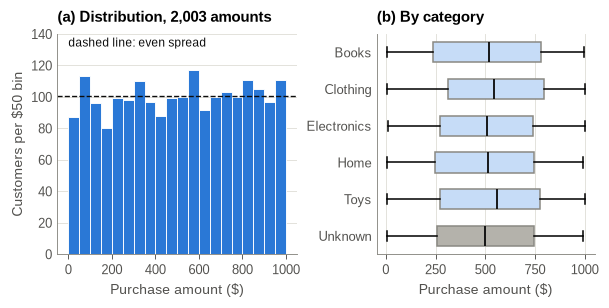

In [27]:
# @title Figure 4: Distribution of purchase amounts and amounts by category

def plot_amounts(df: pd.DataFrame) -> plt.Figure:
    """
    Plots the amount histogram with a uniform reference, and amounts by category.

    Args:
        df: The cleaned register.

    Returns:
        The matplotlib figure.
    """
    amounts = df["PurchaseAmount"].dropna()
    bins = np.arange(0, 1050, 50)
    expected = len(amounts) * 50 / (amounts.max() - amounts.min())

    fig, axes = plt.subplots(1, 2, figsize=(FIG_WIDTH, 2.6), gridspec_kw={"width_ratios": [1.1, 1], "wspace": 0.35})
    ax = axes[0]
    ax.hist(amounts, bins=bins, color=PRIMARY, edgecolor="white", linewidth=0.6)
    ax.axhline(expected, color=INK, linestyle="--", linewidth=0.9)
    ax.set_ylim(0, 140)
    ax.text(0, 132, "dashed line: even spread", ha="left", fontsize=8, color=INK)
    ax.set_xlabel("Purchase amount ($)")
    ax.set_ylabel("Customers per $50 bin")
    ax.set_title("(a) Distribution, 2,003 amounts")
    ax.yaxis.grid(True)
    ax.set_axisbelow(True)

    ax = axes[1]
    cats = ["Books", "Clothing", "Electronics", "Home", "Toys", "Unknown"]
    data = [df.loc[df["ProductCategory"] == c, "PurchaseAmount"].dropna() for c in cats]
    orient = ({"orientation": "horizontal"} if "orientation" in __import__("inspect").signature(ax.boxplot).parameters
              else {"vert": False})
    box = ax.boxplot(data, **orient, widths=0.55, patch_artist=True,
                     medianprops={"color": INK, "linewidth": 1.2}, flierprops={"markersize": 2})
    for patch, c in zip(box["boxes"], cats):
        patch.set_facecolor(MUTED if c == "Unknown" else "#c6dcf7")
        patch.set_edgecolor(AXIS)
    ax.set_yticks(range(1, len(cats) + 1), cats)
    ax.invert_yaxis()
    ax.set_xlabel("Purchase amount ($)")
    ax.set_title("(b) By category")
    ax.xaxis.grid(True)
    ax.set_axisbelow(True)
    return fig


fig = plot_amounts(clean_df)
save_figure(fig, "04_amounts")
plt.show()

## Figure 5 - Purchases through time, and why the pooled monthly chart misleads

Panel (a) is the true time series, one bar per calendar month from October 2022 to July 2025. Panel (b) counts how many years cover each month of the year in this period.

Saved: ./figures/05_monthly.png


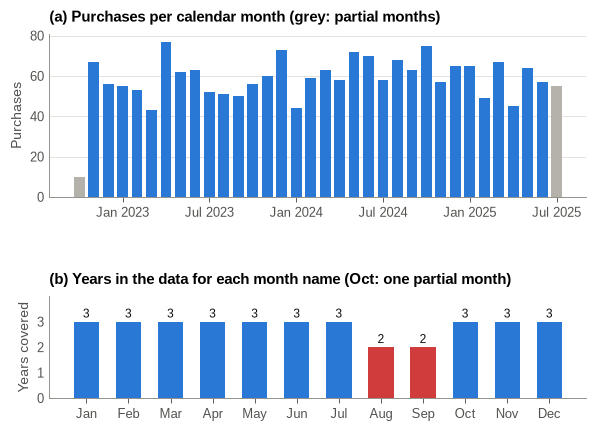

In [28]:
# @title Figure 5: Monthly purchases and coverage of each calendar month

def monthly_series(df: pd.DataFrame) -> pd.Series:
    """
    Counts the purchases per calendar month (year and month).

    Args:
        df: The cleaned register.

    Returns:
        A Series indexed by month period.
    """
    dates = pd.to_datetime(df["PurchaseDate"], errors="coerce").dropna()
    return dates.dt.to_period("M").value_counts().sort_index()


def plot_monthly(series: pd.Series) -> plt.Figure:
    """
    Plots the monthly purchases and the number of years covering each month name.

    Args:
        series: The output of monthly_series.

    Returns:
        The matplotlib figure.
    """
    partial = {series.index.min(), series.index.max()}
    colors = [MUTED if p in partial else PRIMARY for p in series.index]
    coverage = pd.Series(series.index.month).value_counts().reindex(range(1, 13))

    fig, axes = plt.subplots(2, 1, figsize=(FIG_WIDTH, 4.3), gridspec_kw={"height_ratios": [1.6, 1], "hspace": 0.75})
    ax = axes[0]
    x = np.arange(len(series))
    ax.bar(x, series.values, color=colors, width=0.75)
    ticks = [i for i, p in enumerate(series.index) if p.month in (1, 7)]
    ax.set_xticks(ticks, [series.index[i].strftime("%b %Y") for i in ticks])
    ax.set_ylabel("Purchases")
    ax.set_title("(a) Purchases per calendar month (grey: partial months)")
    ax.yaxis.grid(True)
    ax.set_axisbelow(True)

    ax = axes[1]
    cov_colors = [CRITICAL if v == 2 else PRIMARY for v in coverage.values]
    bars = ax.bar([MONTH_NAMES[m] for m in coverage.index], coverage.values, color=cov_colors, width=0.6)
    ax.set_ylim(0, 4)
    ax.set_yticks([0, 1, 2, 3])
    ax.set_ylabel("Years covered")
    ax.set_title("(b) Years in the data for each month name (Oct: one partial month)")
    label_bars_v(ax, bars, [str(v) for v in coverage.values])
    return fig


monthly = monthly_series(clean_df)
monthly.rename("purchases").to_csv(drive_results_path + "by_yearmonth.csv")
fig = plot_monthly(monthly)
save_figure(fig, "05_monthly")
plt.show()

## Figure 6 - Who the customers are

Saved: ./figures/06_demographics.png


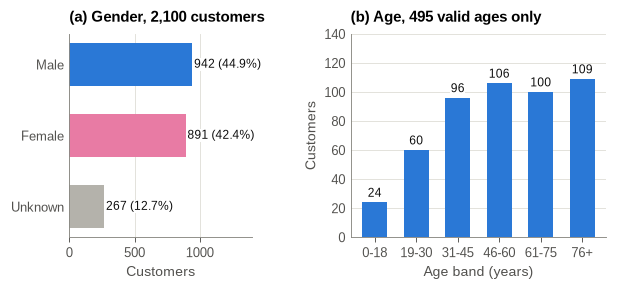

In [29]:
# @title Figure 6: Gender mix and age bands

def plot_demographics(df: pd.DataFrame) -> plt.Figure:
    """
    Plots the gender mix (with the unknown share) and the valid age bands.

    Args:
        df: The cleaned register.

    Returns:
        The matplotlib figure.
    """
    gender = df["Gender"].fillna("Unknown").value_counts().reindex(["Male", "Female", "Unknown"])
    bands = df.loc[df["AgeBand"] != "Unknown", "AgeBand"].value_counts().reindex(AGE_BAND_LABELS)
    n = len(df)

    fig, axes = plt.subplots(1, 2, figsize=(FIG_WIDTH, 2.4), gridspec_kw={"width_ratios": [1, 1.4], "wspace": 0.45})
    ax = axes[0]
    bars = ax.barh(gender.index[::-1], gender.values[::-1],
                   color=[GENDER_COLORS[g] for g in gender.index[::-1]], height=0.6)
    ax.set_xlim(0, 1400)
    ax.set_xlabel("Customers")
    ax.set_title("(a) Gender, 2,100 customers")
    label_bars_h(ax, bars, [f"{v:,} ({v / n * 100:.1f}%)" for v in gender.values[::-1]])
    ax.xaxis.grid(True)
    ax.set_axisbelow(True)

    ax = axes[1]
    bars = ax.bar(bands.index, bands.values, color=PRIMARY, width=0.6)
    ax.set_ylim(0, 140)
    ax.set_xlabel("Age band (years)")
    ax.set_ylabel("Customers")
    ax.set_title(f"(b) Age, {int(bands.sum())} valid ages only")
    label_bars_v(ax, bars, [str(v) for v in bands.values])
    ax.yaxis.grid(True)
    ax.set_axisbelow(True)
    return fig


fig = plot_demographics(clean_df)
save_figure(fig, "06_demographics")
plt.show()

## Figure 7 - Satisfaction

Saved: ./figures/07_ratings.png


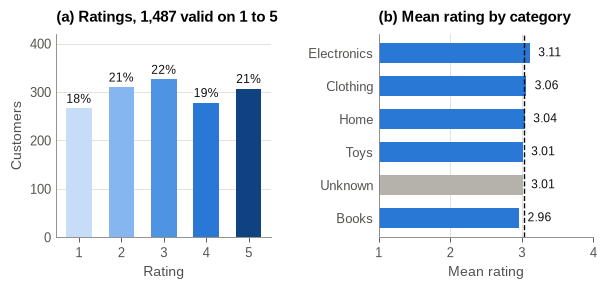

In [30]:
# @title Figure 7: Rating distribution and mean rating by category

def plot_ratings(df: pd.DataFrame, table: pd.DataFrame) -> plt.Figure:
    """
    Plots the distribution of valid ratings and the mean rating by category.

    Args:
        df: The cleaned register.
        table: The summary table by category.

    Returns:
        The matplotlib figure.
    """
    counts = df["Rating"].value_counts().reindex([1.0, 2.0, 3.0, 4.0, 5.0])
    n = int(counts.sum())

    fig, axes = plt.subplots(1, 2, figsize=(FIG_WIDTH, 2.4), gridspec_kw={"wspace": 0.5})
    ax = axes[0]
    bars = ax.bar(["1", "2", "3", "4", "5"], counts.values, color=RATING_COLORS, width=0.6)
    ax.set_ylim(0, 420)
    ax.set_xlabel("Rating")
    ax.set_ylabel("Customers")
    ax.set_title(f"(a) Ratings, {n:,} valid on 1 to 5")
    label_bars_v(ax, bars, [f"{v / n * 100:.0f}%" for v in counts.values])
    ax.yaxis.grid(True)
    ax.set_axisbelow(True)

    ax = axes[1]
    t = table.sort_values("avg_rating")
    colors = [MUTED if c == "Unknown" else PRIMARY for c in t.index]
    bars = ax.barh(t.index, t["avg_rating"], color=colors, height=0.6)
    ax.set_xlim(1, 4)
    ax.axvline(df["Rating"].mean(), color=INK, linestyle="--", linewidth=0.9)
    ax.set_xlabel("Mean rating")
    ax.set_title("(b) Mean rating by category")
    label_bars_h(ax, bars, [f"{v:.2f}" for v in t["avg_rating"]], pad=0.04)
    ax.xaxis.grid(True)
    ax.set_axisbelow(True)
    return fig


fig = plot_ratings(clean_df, summary_tables["category"])
save_figure(fig, "07_ratings")
plt.show()

## Figure 8 - What drives the purchase amount?

Spearman rank correlation between age, amount and rating, each computed on the customers where both values are valid. The number of pairs is written in each cell.

                  Age  PurchaseAmount  Rating
Age             1.000           0.018   0.004
PurchaseAmount  0.018           1.000  -0.027
Rating          0.004          -0.027   1.000


Saved: ./figures/08_correlations.png


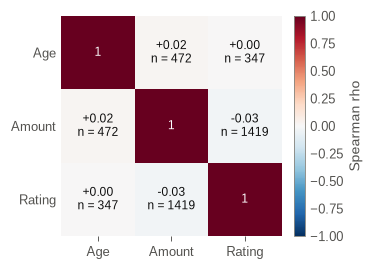

In [31]:
# @title Figure 8: Correlations between age, amount and rating

CORRELATION_VARIABLES = {"Age": "Age", "PurchaseAmount": "Amount", "Rating": "Rating"}


def correlation_table(df: pd.DataFrame) -> tuple:
    """
    Computes the pairwise Spearman correlations and the number of pairs.

    Args:
        df: The cleaned register.

    Returns:
        A tuple (correlation matrix, pair counts).
    """
    cols = list(CORRELATION_VARIABLES)
    rho = df[cols].corr(method="spearman")
    pairs = pd.DataFrame({a: {b: int(df[[a, b]].dropna().shape[0]) for b in cols} for a in cols})
    return rho, pairs


def plot_correlations(rho: pd.DataFrame, pairs: pd.DataFrame) -> plt.Figure:
    """
    Plots the correlation matrix with the coefficient and the number of pairs.

    Args:
        rho: The Spearman correlation matrix.
        pairs: The number of valid pairs for each cell.

    Returns:
        The matplotlib figure.
    """
    labels = list(CORRELATION_VARIABLES.values())
    fig, ax = plt.subplots(figsize=(3.6, 2.6))
    im = ax.imshow(rho.values, cmap="RdBu_r", vmin=-1, vmax=1)
    ax.set_xticks(range(3), labels)
    ax.set_yticks(range(3), labels)
    for i in range(3):
        for j in range(3):
            text = "1" if i == j else f"{rho.values[i, j]:+.2f}\nn = {pairs.values[i, j]}"
            ax.text(j, i, text, ha="center", va="center", fontsize=8,
                    color="white" if abs(rho.values[i, j]) > 0.6 else INK)
    for spine in ax.spines.values():
        spine.set_visible(False)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="Spearman rho")
    return fig


rho, pairs = correlation_table(clean_df)
rho.to_csv(drive_results_path + "correlations.csv")
print(rho.round(3).to_string())
fig = plot_correlations(rho, pairs)
save_figure(fig, "08_correlations")
plt.show()

<a name="statistical-tests"></a>
# 10. Statistical Tests

A difference seen in a chart is a finding only if chance alone is unlikely to produce it. The tests below are non-parametric: amounts and ratings are bounded and not normally distributed.

| Question | Test | Null hypothesis |
|---|---|---|
| Does the amount differ between categories? | Kruskal-Wallis | Same distribution in the five categories |
| Does the amount differ between men and women? | Mann-Whitney U | Same distribution |
| Do `Unknown` purchases differ from the others? | Mann-Whitney U | Same distribution |
| Does the rating mix differ between categories? | Chi-square of independence | Rating independent of category |
| Are purchases evenly spread over the complete months? | Chi-square goodness of fit | Same expected count every month |
| Is the amount related to the rating? | Spearman rank correlation | No monotonic association |
| Is the amount related to age? | Spearman rank correlation | No monotonic association |
| Are amounts spread evenly between their minimum and maximum? | Kolmogorov-Smirnov | Uniform distribution |

In [32]:
# @title Run the statistical tests

def run_tests(df: pd.DataFrame, monthly: pd.Series) -> pd.DataFrame:
    """
    Runs the eight statistical tests of the report.

    Args:
        df: The cleaned register.
        monthly: The purchases per calendar month.

    Returns:
        A DataFrame with the test, its statistic, p-value and base.
    """
    rows = []
    known = df[df["ProductCategory"] != "Unknown"]
    groups = [g["PurchaseAmount"].dropna() for _, g in known.groupby("ProductCategory")]
    h, p = stats.kruskal(*groups)
    rows.append(("Amount by category", "Kruskal-Wallis H", h, p, sum(len(g) for g in groups)))

    men = df.loc[df["Gender"] == "Male", "PurchaseAmount"].dropna()
    women = df.loc[df["Gender"] == "Female", "PurchaseAmount"].dropna()
    u, p = stats.mannwhitneyu(men, women)
    rows.append(("Amount, men against women", "Mann-Whitney U", u, p, len(men) + len(women)))

    unknown = df.loc[df["ProductCategory"] == "Unknown", "PurchaseAmount"].dropna()
    u, p = stats.mannwhitneyu(unknown, known["PurchaseAmount"].dropna())
    rows.append(("Amount, Unknown category against the others", "Mann-Whitney U", u, p,
                 len(unknown) + known["PurchaseAmount"].notna().sum()))

    rated = known.dropna(subset=["Rating"])
    chi2, p, dof, _ = stats.chi2_contingency(pd.crosstab(rated["ProductCategory"], rated["Rating"]))
    rows.append(("Rating mix by category", f"Chi-square ({dof} df)", chi2, p, len(rated)))

    complete = monthly.iloc[1:-1]
    chi2, p = stats.chisquare(complete)
    rows.append((f"Purchases evenly spread over {len(complete)} complete months",
                 f"Chi-square ({len(complete) - 1} df)", chi2, p, int(complete.sum())))

    for col, label in [("Rating", "Amount against rating"), ("Age", "Amount against age")]:
        pair = df[["PurchaseAmount", col]].dropna()
        r, p = stats.spearmanr(pair["PurchaseAmount"], pair[col])
        rows.append((label, "Spearman rho", r, p, len(pair)))

    amounts = df["PurchaseAmount"].dropna()
    d, p = stats.kstest(amounts, "uniform", args=(amounts.min(), amounts.max() - amounts.min()))
    rows.append(("Amounts spread evenly from minimum to maximum", "Kolmogorov-Smirnov D", d, p, len(amounts)))

    table = pd.DataFrame(rows, columns=["test", "statistic_name", "statistic", "p_value", "n"])
    table["significant_at_5%"] = table["p_value"] < 0.05
    return table


tests_df = run_tests(clean_df, monthly)
tests_df.to_csv(drive_results_path + "statistical_tests.csv", index=False)
with pd.option_context("display.float_format", "{:.4f}".format):
    print(tests_df.to_string(index=False))

                                           test       statistic_name   statistic  p_value    n  significant_at_5%
                             Amount by category     Kruskal-Wallis H      3.7198   0.4453 1464              False
                      Amount, men against women       Mann-Whitney U 361889.0000   0.0953 1743              False
    Amount, Unknown category against the others       Mann-Whitney U 380118.0000   0.2088 2003              False
                         Rating mix by category   Chi-square (16 df)      8.3794   0.9368 1072              False
Purchases evenly spread over 32 complete months   Chi-square (31 df)     40.9760   0.1085 1917              False
                          Amount against rating         Spearman rho     -0.0275   0.3011 1419              False
                             Amount against age         Spearman rho      0.0177   0.7018  472              False
  Amounts spread evenly from minimum to maximum Kolmogorov-Smirnov D      0.0186   0.488

In [33]:
# @title The pooled monthly chart against the true monthly series

pooled = clean_df["PurchaseMonthName"].value_counts().reindex(list(MONTH_NAMES.values()))
years_covered = pd.Series(monthly.index.month).value_counts().reindex(range(1, 13)).values
per_year = (pooled / years_covered).round(1)
print(pd.DataFrame({"pooled_count": pooled, "years_covered": years_covered,
                    "mean_per_year": per_year}).to_string())

                   pooled_count  years_covered  mean_per_year
PurchaseMonthName                                            
Jan                         164              3           54.7
Feb                         161              3           53.7
Mar                         173              3           57.7
Apr                         180              3           60.0
May                         198              3           66.0
Jun                         190              3           63.3
Jul                         165              3           55.0
Aug                         119              2           59.5
Sep                         113              2           56.5
Oct                         141              3           47.0
Nov                         184              3           61.3
Dec                         194              3           64.7


**Remark** ✅

- **No segment differs in spending.** The amount does not differ between categories ($p = 0.45$), between men and women ($p = 0.10$) or between `Unknown` and known categories ($p = 0.21$).
- **Satisfaction does not depend on the category** ($p = 0.94$), **and is unrelated to the amount** ($\rho = -0.03$, $p = 0.30$). Age is unrelated to the amount ($\rho = 0.02$, $p = 0.70$, 472 customers).
- **There is no seasonality.** On the 32 complete months, purchases are compatible with an even spread ($p = 0.11$). The low August and September of the pooled chart come from coverage: these two months are present in two years, the others in three. Divided by the years covered, every month lies between 47 and 66 purchases per year.
- **Amounts are spread evenly between $5 and $1,000** ($p = 0.49$): no price point concentrates the sales. This is the signature of a synthetic extract, and it explains why no attribute predicts the amount.

<a name="insights"></a>
# 11. Insights & Recommendations

In [34]:
# @title Export the key findings for the report and the dashboard

kpis = dict(zip(kpi_df["metric"], kpi_df["value"]))
findings = {
    "raw_rows": int(len(raw_df)),
    "duplicates_removed": int(dup_rows),
    "customers": int(kpis["total_customers"]),
    "revenue": float(kpis["total_revenue"]),
    "avg_purchase": float(kpis["avg_purchase"]),
    "median_purchase": float(kpis["median_purchase"]),
    "avg_rating": float(kpis["avg_rating"]),
    "low_rating_pct": float(kpis["low_rating_pct"]),
    "avg_age": float(kpis["avg_age"]),
    "valid_age_pct": float(kpis["valid_age_pct"]),
    "pct_male": float(kpis["pct_male"]),
    "pct_female": float(kpis["pct_female"]),
    "unknown_category": int(kpis["unknown_category"]),
    "invalid_dates": int(kpis["invalid_dates"]),
    "first_purchase": str(pd.to_datetime(clean_df["PurchaseDate"]).min().date()),
    "last_purchase": str(pd.to_datetime(clean_df["PurchaseDate"]).max().date()),
    "tests": tests_df.drop(columns="significant_at_5%").to_dict(orient="records"),
}
with open(drive_results_path + "findings.json", "w") as f:
    json.dump(findings, f, indent=2, default=float)

pprint({k: v for k, v in findings.items() if k != "tests"})

{'avg_age': 54.37171717171717,
 'avg_purchase': 509.8973789316026,
 'avg_rating': 3.0336247478143914,
 'customers': 2100,
 'duplicates_removed': 50,
 'first_purchase': '2022-10-27',
 'invalid_dates': 118,
 'last_purchase': '2025-07-23',
 'low_rating_pct': 38.73570948217888,
 'median_purchase': 519.42,
 'pct_female': 48.608837970540094,
 'pct_male': 51.391162029459906,
 'raw_rows': 2150,
 'revenue': 1021324.45,
 'unknown_category': 565,
 'valid_age_pct': 23.57142857142857}


### 1. Data capture is the first problem to solve
Four of the six quality policies are breached. Only 23.6% of customers have a usable age, 29.2% have no usable rating, 26.9% of purchases have no category and 5.6% carry the sentinel date 32/13/2020. The phone and email columns cannot reach a single customer.

**Recommendation.** Enforce validation at entry: age between 1 and 100, rating widget limited to 1 to 5, mandatory category, calendar date picker, and unique, verified contact details. Keep the automated quality gate (`api/run_quality_alerts.py`, exit code 2 on ALERT) in the publishing path until these rules are in place.

### 2. Revenue is $1,021,324 on 2,003 recorded amounts
The 2,100 customers spent **$1,021,324**, an average ticket of **$509.90** (median $519.42). 97 amounts (4.6%) are missing, so revenue is a recorded total, not a complete one.

**Recommendation.** Publish revenue with its base (2,003 amounts) and make the amount mandatory for closed transactions.

### 3. The Unknown category is the largest "category"
565 purchases (26.9%) have no category, more than Clothing or Electronics (323 each). Their amounts do not differ from the others ($p = 0.21$), so the known shares are a fair guide, but every category total is understated by about a quarter.

**Recommendation.** Make the category mandatory at the point of sale before any assortment decision. Clothing leads revenue ($163,865), Toys trails ($141,384): a gap of 14%, driven by volume, not by ticket ($p = 0.45$).

### 4. No customer attribute predicts spending
Amounts do not differ by gender ($p = 0.10$), category ($p = 0.45$), age ($\rho = 0.02$) or rating ($\rho = -0.03$), and are spread evenly between $5 and $1,000.

**Recommendation.** Do not target campaigns on age, gender or category in this data: none separates high from low spenders. Collect purchase history, channel and basket content, which are the usual drivers of spend.

### 5. Satisfaction is mediocre and polarised
The mean rating is **3.03 / 5**. 38.7% of valid ratings are 1 or 2, a share that does not depend on the category ($p = 0.94$).

**Recommendation.** Start a service-recovery contact for ratings of 1 and 2, and add a reason code to the rating to find the cause.

### 6. The monthly profile shows no seasonality
The dashboard's monthly chart pools October 2022 to July 2025 by month name. August and September look weak only because they appear in two years instead of three. On the true series, purchases are even ($p = 0.11$).

**Recommendation.** Do not plan stock or staff on the pooled chart. Report purchases per calendar month and re-test seasonality once three full years are available.

<a name="dashboard"></a>
# 12. Interactive Dashboard & Quality Alerts

`dashboard.html` is a single self-contained file: open it in a modern browser (Chrome or Edge, then Ctrl+F5), no server and no installation required. Its views (Dashboard, Data Explorer, Live Data, Customers, Products, Trends, Data Quality, Insights, KPI Code) are documented with captures in section 7 of the report.

The project also ships the pipeline that keeps the dashboard data governed:

| Component | File | Role |
|---|---|---|
| ETL | `etl/run_etl.py` | Extract, clean and load `customers_clean.csv`; write `results/etl_audit.json` |
| Quality gate | `api/run_quality_alerts.py` | Compare the clean table with the policy thresholds; exit 0 (OK), 1 (WARN), 2 (ALERT) |
| Notifications | `api/notify_alerts.py`, `api/run_quality_and_notify.py` | Send alerts to console, file, webhook or email |
| Metrics | `api/metrics_server.py` | Expose KPIs and alerts to Prometheus |
| Scheduling | `airflow/customer_analytics_etl_dag.py` | Daily ETL, then quality gate, then publish |
| Monitoring | `grafana/`, `docker-compose.yml` | Prometheus and Grafana dashboards |

> **Reading note.** Three dashboard elements use a different base or rule from this notebook. The *Gender mix* donut is computed on all 2,100 customers (Male 44.9%, Female 42.4%, Unknown 12.7%), while the KPI uses known genders only (51.4% / 48.6%). The *Purchases over time* and *Monthly purchase trend* charts pool all years by month name (see Figure 5). The *Data Quality* view grades the Unknown category as MEDIUM and the rating gap as LOW (1 high, 2 medium, 1 low), while the pipeline policy grades them HIGH and MEDIUM (2 high, 2 medium). Both report the status ALERT. The figures of this notebook are the reference.

In [35]:
# @title Reconcile the dashboard headline figures with the notebook

dashboard_tiles = {
    "Customers": (2100, kpis["total_customers"]),
    "Revenue ($)": (1021324, round(kpis["total_revenue"])),
    "Average ticket ($)": (510, round(kpis["avg_purchase"])),
    "Average rating": (3.03, round(kpis["avg_rating"], 2)),
    "Average age": (54.4, round(kpis["avg_age"], 1)),
    "Duplicates removed": (50, dup_rows),
    "Invalid dates": (118, kpis["invalid_dates"]),
}
recon = pd.DataFrame(dashboard_tiles, index=["dashboard", "notebook"]).T
recon["agree"] = recon["dashboard"] == recon["notebook"]
recon

,dashboard,notebook,agree
Customers,2100.00,2100.00,True
Revenue ($),1021324.00,1021324.00,True
Average ticket ($),510.00,510.00,True
Average rating,3.03,3.03,True
Average age,54.40,54.40,True
Duplicates removed,50.00,50.00,True
Invalid dates,118.00,118.00,True


<a name="limitations"></a>
# 13. Limitations & Future Works

* **One purchase per customer.** No repeat-purchase, retention or lifetime-value indicator can be computed.

* **Age rests on 495 customers** (23.6%), and its distribution is not representative of the 1,605 others. Age bands are shown for description only.

* **Ratings rest on 1,487 customers** (70.8%), and the 291 values of 10 may hide true scores of 1 or 5 typed on another scale.

* **The extract looks synthetic.** 48 distinct names, two phone numbers, 144 emails and amounts spread evenly from $5 to $1,000. Methods and pipeline transfer to real data; the business conclusions must be re-tested on it.

* **Association, not causation.** The absence of a relationship between spend and the attributes recorded does not exclude drivers that are not recorded.

**Future works.** Repair the capture at source, then re-run this notebook and the ETL unchanged: every flag, table and figure is recomputed from the primary columns. Add a transaction table (several purchases per customer, channel, basket) to measure retention and customer value.

<a name="references"></a>
# 14. References

* Gebru, T. et al. (2021). Datasheets for Datasets. *Communications of the ACM*, 64(12): https://arxiv.org/abs/1803.09010
* Kruskal, W. H. and Wallis, W. A. (1952). Use of ranks in one-criterion variance analysis. *Journal of the American Statistical Association*, 47(260), 583-621.
* Mann, H. B. and Whitney, D. R. (1947). On a test of whether one of two random variables is stochastically larger than the other. *Annals of Mathematical Statistics*, 18(1), 50-60.
* Spearman, C. (1904). The proof and measurement of association between two things. *American Journal of Psychology*, 15(1), 72-101.
* Virtanen, P. et al. (2020). SciPy 1.0: fundamental algorithms for scientific computing in Python. *Nature Methods*, 17, 261-272.
* Hunter, J. D. (2007). Matplotlib: a 2D graphics environment. *Computing in Science & Engineering*, 9(3), 90-95.
* McKinney, W. (2010). Data structures for statistical computing in Python. *Proceedings of the 9th Python in Science Conference*, 56-61.